In [1]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

/tmp/ipykernel_1074/3543475752.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_totalprice.index, y=correlation_with_totalprice["TotalPrice"], palette='coolwarm')


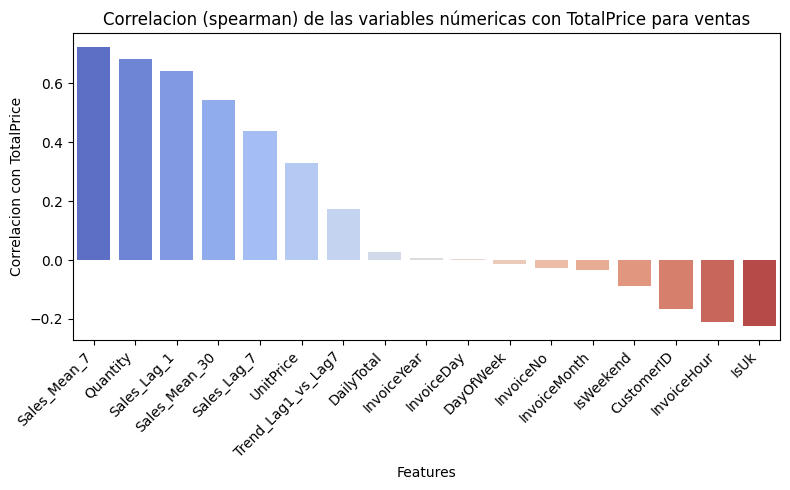

/tmp/ipykernel_1074/3543475752.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_totalprice.index, y=correlation_with_totalprice["TotalPrice"], palette='coolwarm')


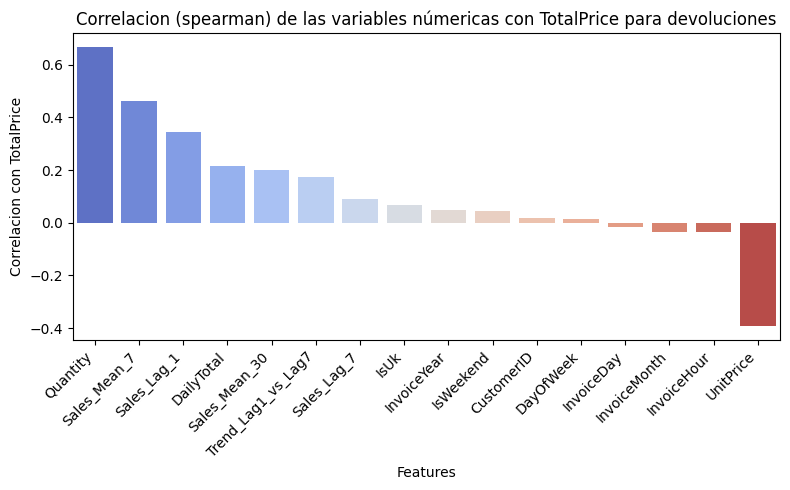

/tmp/ipykernel_1074/3543475752.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_totalprice.index, y=correlation_with_totalprice["TotalPrice"], palette='coolwarm')


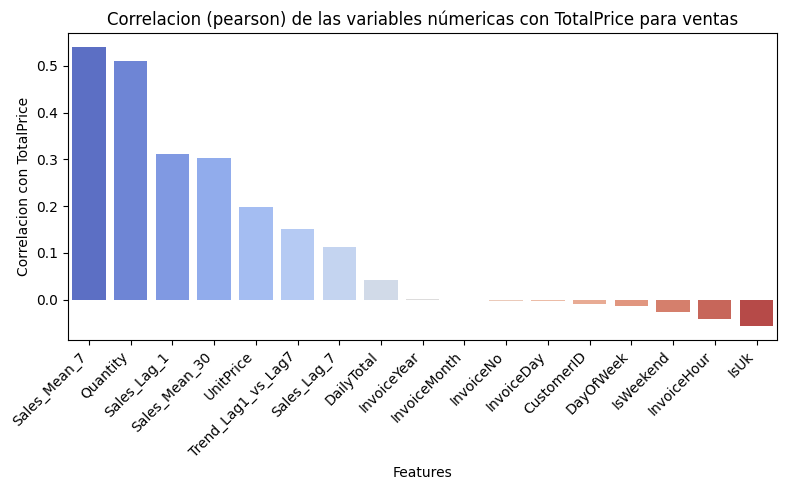

/tmp/ipykernel_1074/3543475752.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_totalprice.index, y=correlation_with_totalprice["TotalPrice"], palette='coolwarm')


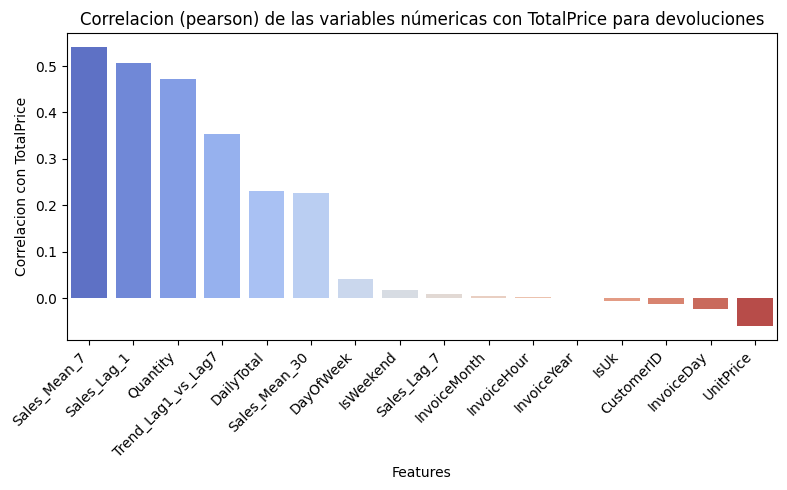

In [6]:

df_ventas = pd.read_csv("/content/data_v07_con_fechas_regresion_ventas.csv", encoding="cp1252")
df_devoluciones = pd.read_csv( "/content/data_v07_con_fechas_regresion_devoluciones.csv",encoding="cp1252")

def addColumnsByFeatureEngineering(dataset: pd.DataFrame) -> pd.DataFrame:

  #1 Añadimos la variable isWeekend para saber si la transaccion es en fin de semana o no
  dataset["IsWeekend"] =  np.where(dataset["DayOfWeek"] >=5, 1, 0)
  #2 Añadimos las columnas temporales (Lag Features y ventanas deslizantes)
  dataset["Sales_Lag_1"] = dataset["TotalPrice"].shift(1)
  dataset["Sales_Lag_7"] = dataset["TotalPrice"].shift(7)
  dataset["Sales_Mean_7"] = dataset["TotalPrice"].rolling(7).mean()
  dataset["Sales_Mean_30"] = dataset["TotalPrice"].rolling(30).mean()

  #3 Creamos una feature de tendencia como resultado de la diferencia entre Lag1 - Lag7
  dataset["Trend_Lag1_vs_Lag7"] = dataset["Sales_Lag_1"] - dataset["Sales_Lag_7"]

  # Creamos la columna fecha a partir de día, mes y año
  dataset["InvoiceDate"] = pd.to_datetime(dataset[["InvoiceYear", "InvoiceMonth", "InvoiceDay"]].rename(
    columns={"InvoiceYear": "year", "InvoiceMonth": "month", "InvoiceDay": "day"}
    ))

  # Añadimos la variable objetivo de DailyTotal
  dataset["DailyTotal"] = dataset.groupby("InvoiceDate")["TotalPrice"].transform("sum")

  return dataset


# Convert only 'TotalPrice' to numeric, coercing errors
if 'TotalPrice' in df_ventas.columns:
    df_ventas['TotalPrice'] = pd.to_numeric(df_ventas['TotalPrice'], errors='coerce')
if 'TotalPrice' in df_devoluciones.columns:
    df_devoluciones['TotalPrice'] = pd.to_numeric(df_devoluciones['TotalPrice'], errors='coerce')

# Eliminamos posibles Nan
df_ventas.dropna(subset=['TotalPrice'], inplace=True)

df_ventas = addColumnsByFeatureEngineering(df_ventas)
df_devoluciones = addColumnsByFeatureEngineering(df_devoluciones)


def plot_correlation_with_totalprice(df: pd.DataFrame, title_suffix: str, method='spearman'):
  #Mostramos la correlacion de todas las variables numericas con la variable objetivo TotalPrice en un grafico de barras
  plt.figure(figsize=(8,5))
  correlation_with_totalprice = df.corr(method=method,numeric_only=True)[["TotalPrice"]].sort_values(by="TotalPrice", ascending=False).drop("TotalPrice")
  sns.barplot(x=correlation_with_totalprice.index, y=correlation_with_totalprice["TotalPrice"], palette='coolwarm')
  plt.title(f'Correlacion ({method}) de las variables númericas con TotalPrice para {title_suffix}')
  plt.xlabel('Features')
  plt.ylabel('Correlacion con TotalPrice')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

#Mostramos graficos de correlacion con lla variable objetivo
plot_correlation_with_totalprice(df_ventas, 'ventas', method='spearman')
plot_correlation_with_totalprice(df_devoluciones, 'devoluciones', method='spearman')

plot_correlation_with_totalprice(df_ventas, 'ventas', method='pearson')
plot_correlation_with_totalprice(df_devoluciones, 'devoluciones', method='pearson')

In [7]:
#Funcion para generar los csv tanto para ventas como devoluciones
def generateCsv(dfVentas: pd.DataFrame, dfDevoluciones: pd.DataFrame) -> None:
  print("Generating CSV for df_ventas...")
  dfVentas.to_csv('data_v01_clustering_ventas.csv', index=False)
  print("CSV 'data_v01_clustering_ventas.csv' created.")

  print("Generating CSV for df_devoluciones...")
  dfDevoluciones.to_csv('data_v01_clustering_devoluciones.csv', index=False)
  print("CSV 'data_v01_clustering_devoluciones.csv' created.")

  from google.colab import files

  files.download('data_v01_clustering_ventas.csv')
  files.download('data_v01_clustering_devoluciones.csv')



generateCsv(dfVentas=df_ventas, dfDevoluciones=df_devoluciones)

Generating CSV for df_ventas...
CSV 'data_v01_clustering_ventas.csv' created.
Generating CSV for df_devoluciones...
CSV 'data_v01_clustering_devoluciones.csv' created.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>